In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
dataset = pd.DataFrame([[1000],[2000],[3000],[4000],[5000],[6000],[7000],[8000],[9000],[20000000],[10000000000]], columns=['salary'])
dataset

,salary
0,1000
1,2000
2,3000
3,4000
4,5000
5,6000
6,7000
7,8000
8,9000
9,20000000


In [3]:
# EDA --- Exploratory Data Analysis
# Data Exploration
#
#
#                     EDA
#                      |
#     ---------------------------------------
#     |                                     |
#. Numerical Based                   Visual based
#  EDA                               EDA

In [4]:
#Numerical Based EDA
#
#
pd.set_option('display.float_format', '{:.2f}'.format)
#

# describe() in pandas is responsible to calculate and display statistical summary

dataset['salary'].describe()

count            11.00
mean      910913181.82
std      3014515034.42
min            1000.00
25%            3500.00
50%            6000.00
75%            8500.00
max     10000000000.00
Name: salary, dtype: float64

In [ ]:
# Check mean and 50% --- if they are nearby , chances of outliers are negligble
#                        if they are far, outliers are influencing the data

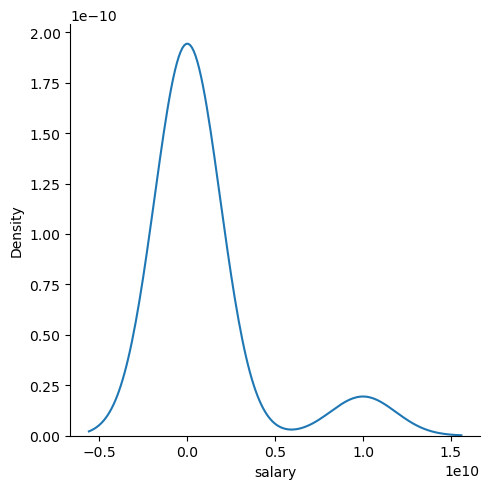

In [5]:
#Visual way
# Distribution PLot

sns.displot(data=dataset['salary'],kind='kde')


In [6]:
dataset['salary'].mean()

np.float64(910913181.8181819)

In [7]:
# Calc Quartiles using Numpy

np.percentile(dataset['salary'],[25,50,75])


array([3500., 6000., 8500.])

In [8]:
# Calc Quartiles using Pandas

dataset['salary'].quantile([0.25,0.50,0.75,1])

0.25          3500.00
0.50          6000.00
0.75          8500.00
1.00   10000000000.00
Name: salary, dtype: float64

In [9]:

# Use Tukeys Method to identify valid range

def outlierDetection(column):
  #Sort the data in asc order

  sorted(column)

  #Calc Q1 and Q3
  Q1,Q3 = np.percentile(column,[25,75])

  #Calc IQR
  IQR = Q3 - Q1

  # Calc Valid Range
  lowerRange = Q1 - (1.5 * IQR)
  upperRange = Q3 + (1.5 * IQR)

  return lowerRange,upperRange

In [10]:
lr,ur = outlierDetection(dataset['salary'])

In [11]:
lr,ur

(np.float64(-4000.0), np.float64(16000.0))

In [12]:
#Outliers

dataset[ (dataset['salary'] < lr) | (dataset['salary'] > ur) ]

,salary
9,20000000
10,10000000000


In [13]:
#Remove Outliers

processedData = dataset[ ~( (dataset['salary'] < lr) | (dataset['salary'] > ur) ) ]
processedData

,salary
0,1000
1,2000
2,3000
3,4000
4,5000
5,6000
6,7000
7,8000
8,9000


In [14]:
processedData.describe()

,salary
count,9.00
mean,5000.00
std,2738.61
min,1000.00
25%,3000.00
50%,5000.00
75%,7000.00
max,9000.00


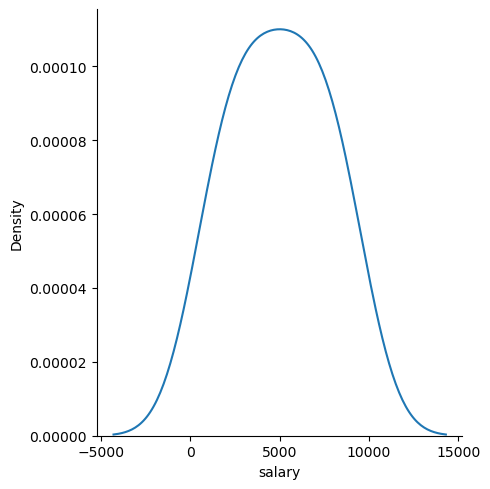

In [15]:
sns.displot(processedData['salary'], kind='kde')

In [16]:
processedData['salary'].mean()

np.float64(5000.0)